# Defects Analysis
In this sample csv file, each row has 8 columns:
1. **defect_id** — unique identifier for each defect
2. **product_id** — which product the defect was found on
3. **defect_type** — Structural, Functional, or Cosmetic
4. **defect_date** — date the defect was recorded
5. **defect_location** — where on the product: Component, Internal, or Surface
6. **severity** — Minor, Moderate, or Critical
7. **inspection_method** — Visual Inspection, Manual Testing, or Automated Testing
8. **repair_cost** — cost in dollars to fix the defect

We can conduct an analysis of this data using pandas, matplot, and seaborn and use it to show valuable data for potential stakeholders. First of all, what defect types are the most common?

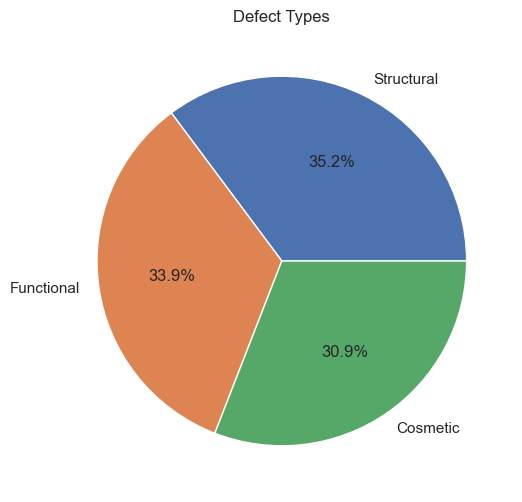

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("defects_data.csv")

df['defect_type'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6))
plt.title('Defect Types')
plt.ylabel('')
plt.show()

It looks like the defect types occur with a pretty similar rate to each other. 

Defects are listed in this CSV as minor, moderate, or critical. If we want to see where critical errors are occuring with greatest frequency, we can use a heatmap to categorize these by location and type:

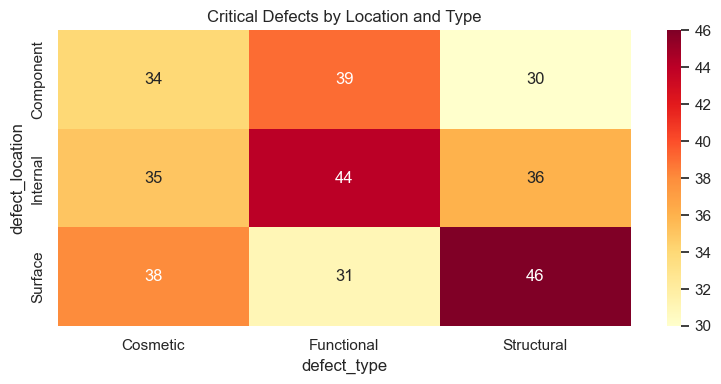

In [53]:
pivot = df.pivot_table(index='defect_location', columns='defect_type', values='severity', aggfunc=lambda x: (x == 'Critical').sum())

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Critical Defects by Location and Type')
plt.tight_layout()
plt.show()

Apparently, Surface Structural defects and Internal Functional defects are the most common type of critical defects.

What products are the most likely to need to be repaired? We can create a bar chart to compare this. 

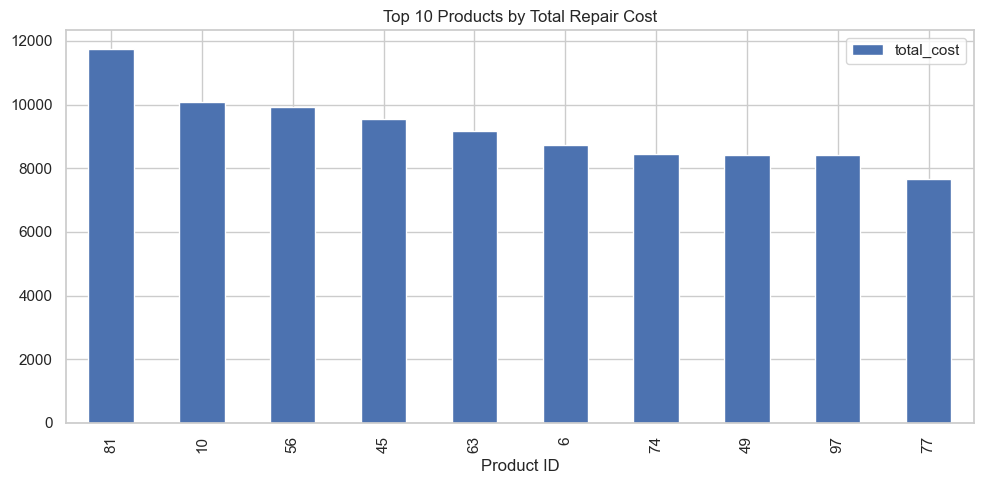

In [54]:
product = df.groupby('product_id').agg(
    total_cost=('repair_cost', 'sum')
)

top10 = product.sort_values('total_cost', ascending=False).head(10)
top10.plot.bar(figsize=(10, 5))
plt.title('Top 10 Products by Total Repair Cost')
plt.xlabel('Product ID')
plt.tight_layout()
plt.show()

Looks like product 81 is accruing the greatest repair cost. 

We want to see if we can improve costs by using better inspection methods. We can do this by comparing costs to inspection methods.

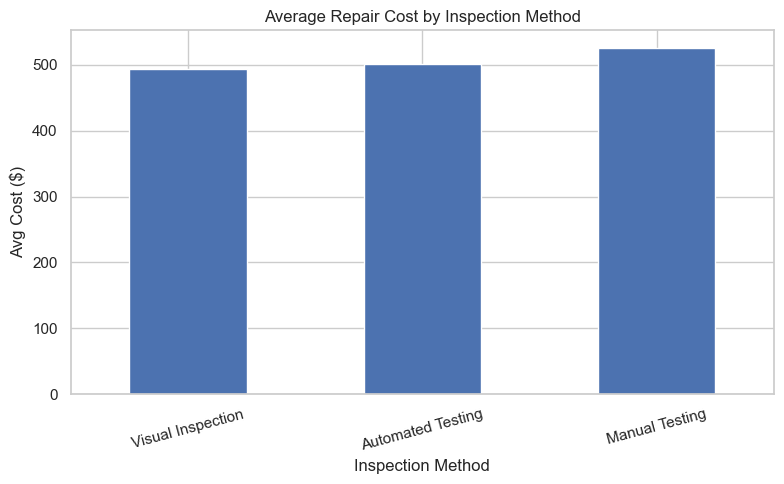

In [55]:
avg_cost = df.groupby('inspection_method')['repair_cost'].mean().sort_values()

avg_cost.plot.bar(figsize=(8, 5))
plt.title('Average Repair Cost by Inspection Method')
plt.xlabel('Inspection Method')
plt.ylabel('Avg Cost ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Okay, it looks like the inspection method does not significantly affect the cost of repair.

Lastly, we want to know if defects are increasing or decreasing over time.

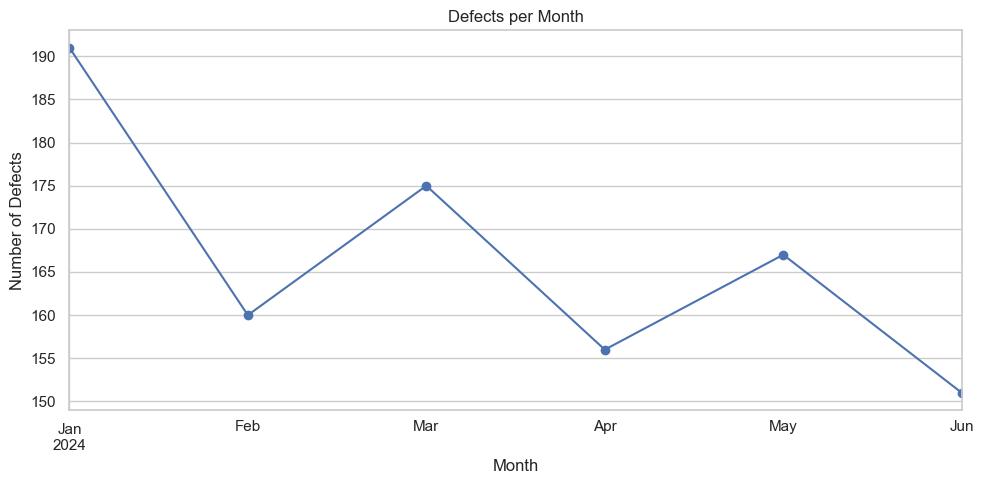

In [56]:
df['defect_date'] = pd.to_datetime(df['defect_date'])
monthly = df.groupby(df['defect_date'].dt.to_period('M')).size()

monthly.plot.line(figsize=(10, 5), marker='o')
plt.title('Defects per Month')
plt.xlabel('Month')
plt.ylabel('Number of Defects')
plt.tight_layout()
plt.show()

It looks like the amount of defects are decreasing. We start with around 190 defects and end with around 150. Clearly the trend is going in a positive direction. 

Overall, this analysis gives us a clear picture of where defects are coming from and what they're costing us. Defect types are fairly evenly spread, but Surface Structural and Internal Functional defects are the ones most likely to be critical, so those are worth keeping an eye on. Product 81 stands out as the most expensive to repair by a clear margin. Inspection method doesn't seem to make a difference to repair cost, which suggests the issue is in the products themselves rather than how we're finding the problems. The good news is that defects are trending downward over the 6 month period.